# Notebook 3B: Frontal Position and Envelope Width Trends

This notebook focuses on **frontal latitude** and **envelope width** trends by sector.

It builds two figures:
1. Sector time series (monthly + 12-month rolling mean + Theil-Sen trend).
2. Sector bar trends with 95% CI and significance stars.

## Trend methodology
- **Trend estimator:** Theil-Sen robust median slope.
- **Significance test:** Mann-Kendall trend test.
- **Significance labels:** `* p<0.05`, `** p<0.01`, `*** p<0.001`.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Paths
REPO_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), '..')))
if not (REPO_ROOT / 'outputs' / 'trends').exists() and (Path.cwd() / 'outputs' / 'trends').exists():
    REPO_ROOT = Path.cwd()

INPUT_DIR = REPO_ROOT / 'outputs' / 'trends'
PLOT_DIR = REPO_ROOT / 'outputs' / 'plots' / 'trends_split'
FIG_DIR = REPO_ROOT / 'figures' / 'manuscript'   # publication figures (tracked by git)
FIG_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

SECTOR_ORDER = ['Indian', 'Pacific', 'Atlantic']
SECTOR_COLORS = ['#2A9D8F', '#457B9D', '#E07A5F']

STYLE = {
    'raw_alpha': 0.18,
    'raw_lw': 0.7,
    'smooth_lw': 1.9,
    'trend_lw': 1.4,
    'grid_alpha': 0.18,
    'grid_lw': 0.5,
    'axis_label_size': 11,
    'title_size': 11,
    'tick_size': 9,
    'annot_size': 7,
    'panel_size': 11,
    'neutral': '#7A8288',
    'series_lat': "#5285A0",
    'series_wid': "#9D2A90",
    'trend_sig': '#1F2933',
}

plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size':         10,
    'axes.labelsize':    STYLE['axis_label_size'],
    'axes.titlesize':    STYLE['title_size'],
    'axes.titleweight':  'bold',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'axes.linewidth':    0.6,
    'figure.facecolor':  'white',
    'grid.alpha':        0.18,
    'grid.linewidth':    0.5,
    'xtick.labelsize':   STYLE['tick_size'],
    'ytick.labelsize':   STYLE['tick_size'],
    'legend.fontsize':   8,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  '#cccccc',
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})


def panel_label(ax, label):
    ax.text(
        0.015,
        0.985,
        f'({label})',
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=STYLE['panel_size'],
        fontweight='semibold',
        color='#1F2933',
    )


def base_timeseries_style(ax):
    ax.grid(alpha=STYLE['grid_alpha'], lw=STYLE['grid_lw'])
    ax.tick_params(length=3.0, width=0.7, color='#67727A')


def stars(p):
    if not np.isfinite(p):
        return ''
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''


def theil_sen_with_ci(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return {'slope': np.nan, 'intercept': np.nan, 'lo': np.nan, 'hi': np.nan, 'se': np.nan}

    res = stats.theilslopes(y[m], x[m], alpha=0.95)
    slope = float(res.slope)
    intercept = float(res.intercept)
    lo = float(res.low_slope)
    hi = float(res.high_slope)
    se = (hi - lo) / (2 * 1.96) if np.isfinite(lo) and np.isfinite(hi) else np.nan
    return {'slope': slope, 'intercept': intercept, 'lo': lo, 'hi': hi, 'se': se}


def _mk_s_var(y):
    n = len(y)
    s = 0
    for i in range(n - 1):
        s += np.sign(y[i + 1:] - y[i]).sum()

    _, counts = np.unique(y, return_counts=True)
    tie_term = np.sum(counts * (counts - 1) * (2 * counts + 5))
    var_s = (n * (n - 1) * (2 * n + 5) - tie_term) / 18.0
    return s, var_s


def mann_kendall(y):
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    n = len(y)
    if n < 5:
        return {'tau': np.nan, 'p': np.nan}

    s, var_s = _mk_s_var(y)
    tau = s / (0.5 * n * (n - 1))

    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s)
    else:
        z = 0.0

    p = 2 * stats.norm.sf(np.abs(z))
    return {'tau': float(tau), 'p': float(p)}


print(f'Input: {INPUT_DIR}')
print(f'Output: {PLOT_DIR}')


Input: outputs/trends
Output: outputs/plots/trends_split


In [2]:
sector_ts = pd.read_csv(INPUT_DIR / 'sector_timeseries.csv')

available = sorted(set(sector_ts['sector'].unique()))
sectors = [s for s in SECTOR_ORDER if s in available]
if len(sectors) < 3:
    sectors = [s for s in available if s != 'Whole SO'][:3]

whole_so_label = 'Whole SO'
has_whole_so = whole_so_label in available
timeseries_groups = sectors + ([whole_so_label] if has_whole_so else [])
bar_groups = sectors

print('Sectors used:', sectors)
print('Groups used (time series):', timeseries_groups)
print('Groups used (bar trends):', bar_groups)
print('Rows in sector time series:', len(sector_ts))

Sectors used: ['Indian', 'Pacific', 'Atlantic']
Groups used (time series): ['Indian', 'Pacific', 'Atlantic', 'Whole SO']
Groups used (bar trends): ['Indian', 'Pacific', 'Atlantic']
Rows in sector time series: 1200


## Figure B1: Frontal Latitude and Envelope Width Time Series by Sector + Whole SO

Top row: median frontal latitude. Bottom row: mean envelope width.

Trend lines use **Theil-Sen** slopes and significance comes from **Mann-Kendall** p-values.
The **Whole SO** column is included when available in the input table.

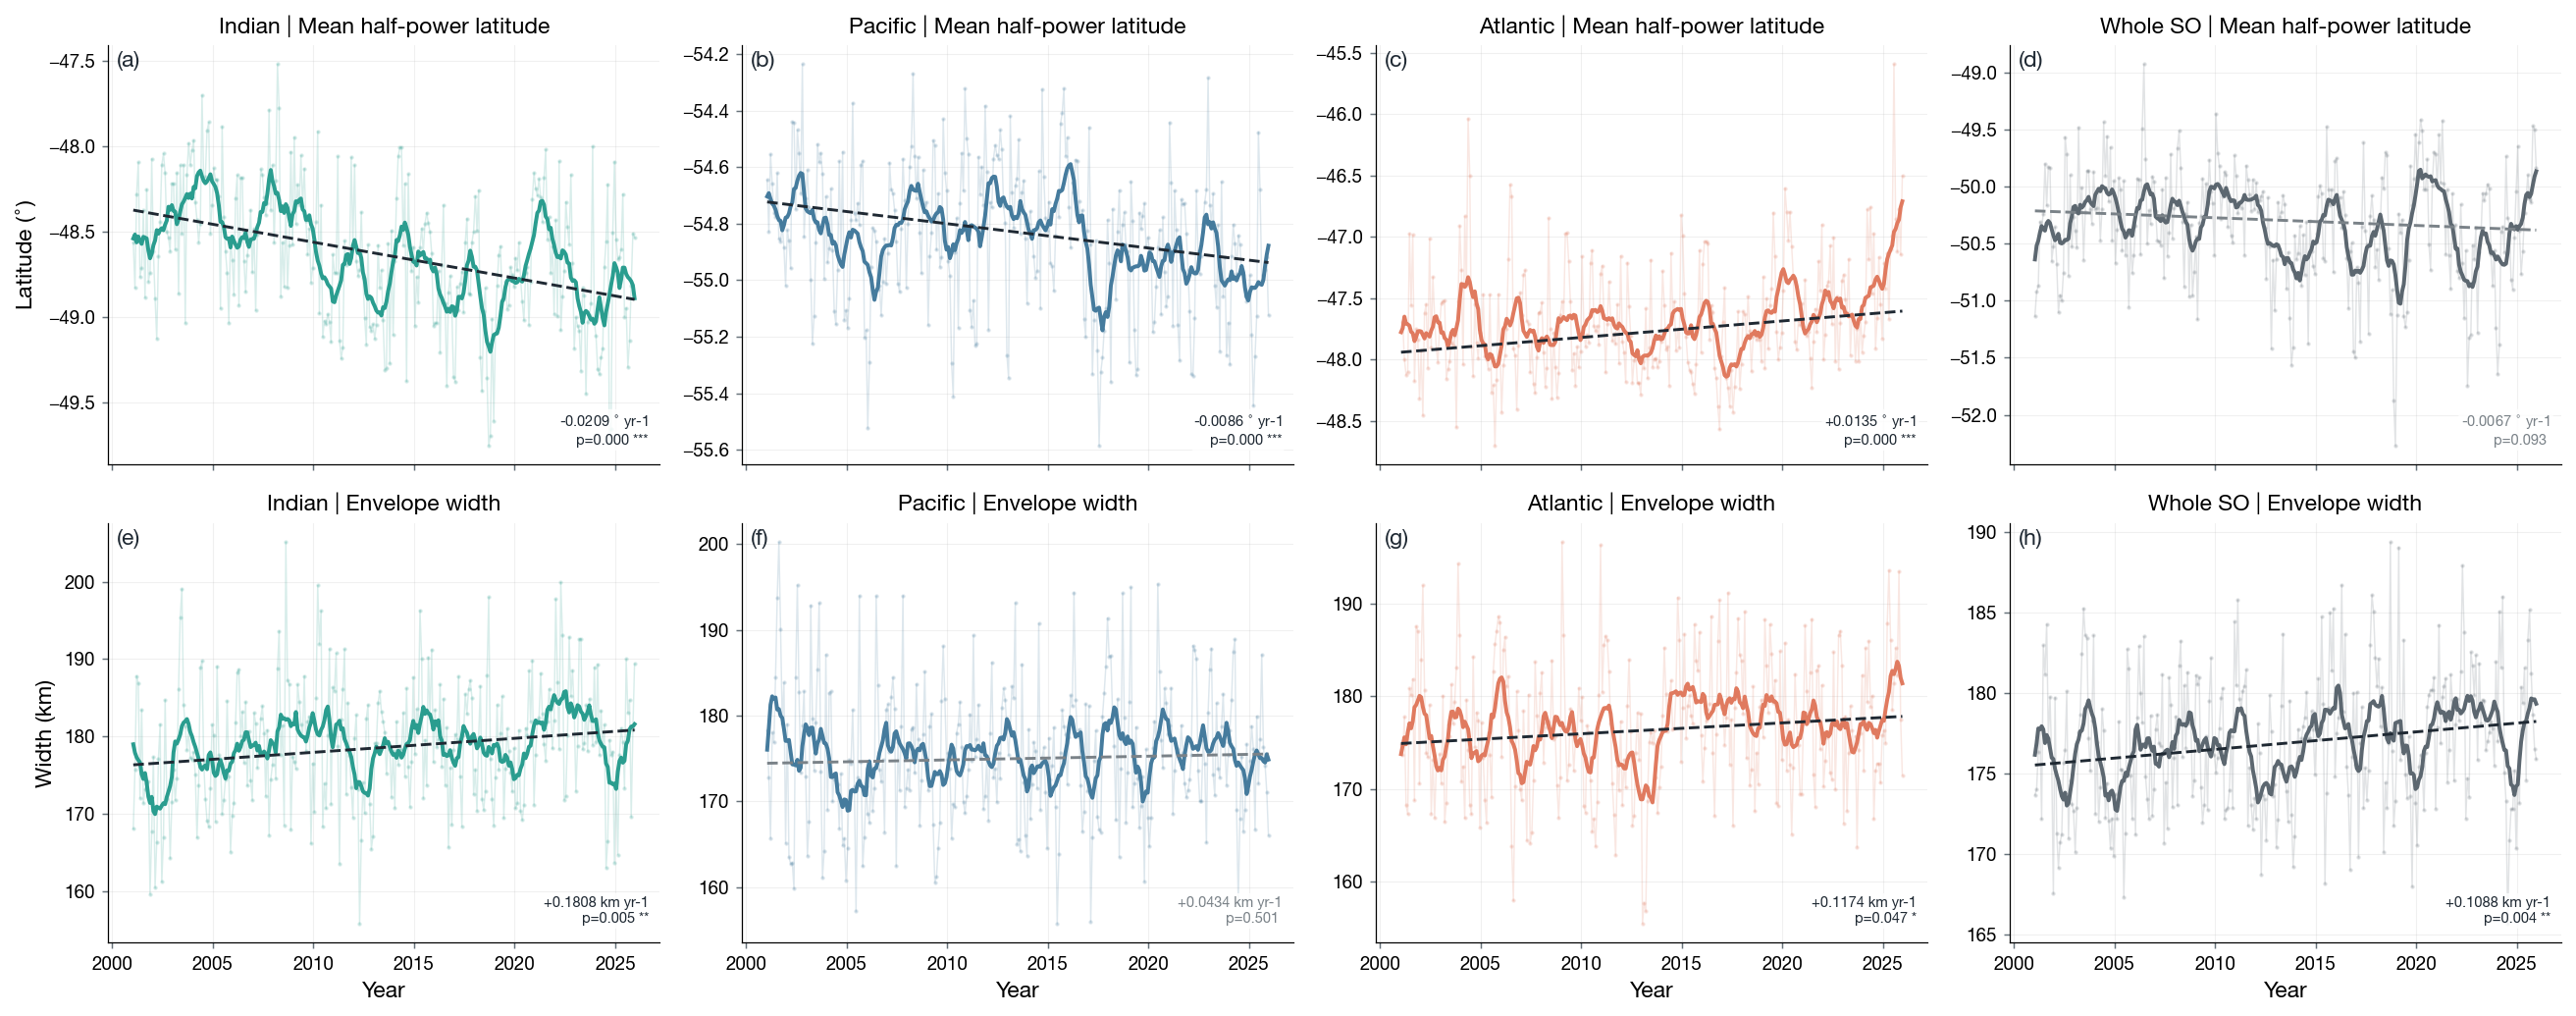

Saved: outputs/plots/trends_split/figB1_fronts_width_timeseries_by_sector.png


In [3]:
ncols = len(timeseries_groups)
fig, axes = plt.subplots(2, ncols, figsize=(4.4 * ncols, 7), sharex=True)

rows = [
    ('median_lat', 'Mean half-power latitude', r'$^{\circ}$', STYLE['series_lat']),
    ('mean_width_km', 'Envelope width', 'km', STYLE['series_wid']),
]
panel_ids = [chr(ord('a') + i) for i in range(2 * ncols)]
panel_idx = 0

for r, (col, label, unit, line_color) in enumerate(rows):
    for c, group_name in enumerate(timeseries_groups):
        ax = axes[r, c]
        grp = sector_ts[sector_ts['sector'] == group_name].sort_values('decimal_year')
        x = grp['decimal_year'].values.astype(float)
        y = grp[col].values.astype(float)

        if group_name in sectors:
            sector_color = SECTOR_COLORS[sectors.index(group_name)]
        else:
            sector_color = '#5C6770'

        ax.plot(x, y, color=sector_color, alpha=STYLE['raw_alpha'], marker='.', ms=2.2, lw=STYLE['raw_lw'])
        if len(grp) >= 12:
            y_rm = pd.Series(y).rolling(12, center=True, min_periods=6).mean()
            ax.plot(x, y_rm, color=sector_color, lw=STYLE['smooth_lw'])

        ts_res = theil_sen_with_ci(x, y)
        mk_res = mann_kendall(y)

        if np.isfinite(ts_res['slope']):
            xf = np.array([np.nanmin(x), np.nanmax(x)])
            trend_col = STYLE['trend_sig'] if (np.isfinite(mk_res['p']) and mk_res['p'] < 0.05) else STYLE['neutral']
            ax.plot(xf, ts_res['intercept'] + ts_res['slope'] * xf, color=trend_col, ls='--', lw=STYLE['trend_lw'])
            txt = f"{ts_res['slope']:+.4f} {unit} yr-1\np={mk_res['p']:.3f} {stars(mk_res['p'])}"
            ax.text(
                0.98,
                0.04,
                txt,
                transform=ax.transAxes,
                ha='right',
                va='bottom',
                fontsize=STYLE['annot_size'],
                color=trend_col,
                bbox=dict(facecolor='white', alpha=0.82, edgecolor='none', boxstyle='round,pad=0.2'),
            )

        ax.set_title(f'{group_name} | {label}')
        if c == 0:
            ylabel = r'Latitude ($^{\circ}$)' if col == 'median_lat' else 'Width (km)'
            ax.set_ylabel(ylabel)
        if r == 1:
            ax.set_xlabel('Year')

        base_timeseries_style(ax)
        panel_label(ax, panel_ids[panel_idx])
        panel_idx += 1

fig.tight_layout()
out_fig = PLOT_DIR / 'figB1_fronts_width_timeseries_by_sector.png'
fig.savefig(out_fig, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out_fig}')

## Figure B2: Whole SO Time Series + Sector Bar Trends

Combined 2x2 figure:
- Top row: **Whole SO** time series (monthly, 12-month rolling mean, Theil-Sen trend).
- Bottom row: sector bar trends with 95% CI and Mann-Kendall significance stars.

/var/folders/ms/8hpcnj2j01zd81g0v_5l2ttw0000gn/T/ipykernel_8398/2837813437.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


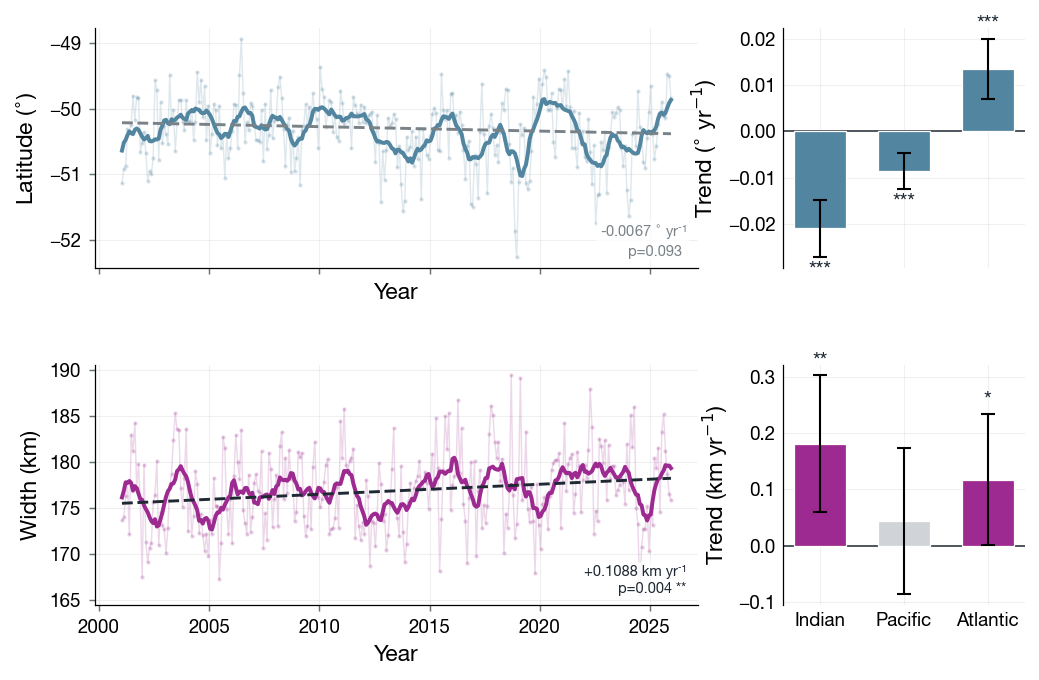

Saved: outputs/plots/trends_split/figB2_wholeSO_timeseries_and_sector_bars.png


In [4]:
group_name = 'Whole SO' if 'Whole SO' in set(sector_ts['sector'].unique()) else sectors[0]
if group_name != 'Whole SO':
    print("Whole SO not found; using first available sector for Figure B2 time series:", group_name)

grp = sector_ts[sector_ts['sector'] == group_name].sort_values('decimal_year')
x = grp['decimal_year'].values.astype(float)
bar_groups = sectors

# Precompute sector bar-trend metrics
lat_s, lat_e, lat_p = [], [], []
wid_s, wid_e, wid_p = [], [], []
for sec in bar_groups:
    g = sector_ts[sector_ts['sector'] == sec].sort_values('decimal_year')
    xx = g['decimal_year'].values.astype(float)

    yy = g['median_lat'].values.astype(float)
    ts_lat = theil_sen_with_ci(xx, yy)
    mk_lat = mann_kendall(yy)
    lat_s.append(ts_lat['slope'])
    lat_e.append(1.96 * ts_lat['se'] if np.isfinite(ts_lat['se']) else np.nan)
    lat_p.append(mk_lat['p'])

    yy = g['mean_width_km'].values.astype(float)
    ts_wid = theil_sen_with_ci(xx, yy)
    mk_wid = mann_kendall(yy)
    wid_s.append(ts_wid['slope'])
    wid_e.append(1.96 * ts_wid['se'] if np.isfinite(ts_wid['se']) else np.nan)
    wid_p.append(mk_wid['p'])

fig, axes = plt.subplots(2, 2, figsize=(8,5), gridspec_kw={'hspace': 0.4, 'width_ratios': [1.0, 0.4]}, sharex='col')

# Top row: Whole SO time series
series_defs = [
    ('median_lat', 'Mean Half-power Latitude', r'Latitude ($^{\circ}$)', STYLE['series_lat'], r'$^{\circ}$'),
    ('mean_width_km', 'Envelope Width', 'Width (km)', STYLE['series_wid'], 'km'),
]
for i_ax, (col, title, ylabel, line_color, unit) in enumerate(series_defs):
    ax = axes[i_ax, 0]
    y = grp[col].values.astype(float)

    ax.plot(x, y, color=line_color, alpha=STYLE['raw_alpha'], marker='.', ms=2.2, lw=STYLE['raw_lw'])
    if len(grp) >= 12:
        y_rm = pd.Series(y).rolling(12, center=True, min_periods=6).mean()
        ax.plot(x, y_rm, color=line_color, lw=STYLE['smooth_lw'])

    ts_res = theil_sen_with_ci(x, y)
    mk_res = mann_kendall(y)
    if np.isfinite(ts_res['slope']):
        xf = np.array([np.nanmin(x), np.nanmax(x)])
        trend_col = STYLE['trend_sig'] if (np.isfinite(mk_res['p']) and mk_res['p'] < 0.05) else STYLE['neutral']
        ax.plot(xf, ts_res['intercept'] + ts_res['slope'] * xf, color=trend_col, ls='--', lw=STYLE['trend_lw'])
        txt = f"{ts_res['slope']:+.4f} {unit} yr⁻¹\np={mk_res['p']:.3f} {stars(mk_res['p'])}"
        ax.text(
            0.98,
            0.04,
            txt,
            transform=ax.transAxes,
            ha='right',
            va='bottom',
            fontsize=STYLE['annot_size'],
            color=trend_col,
            bbox=dict(facecolor='white', alpha=0.82, edgecolor='none', boxstyle='round,pad=0.2'),
        )
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Year')
    base_timeseries_style(ax)

# Bottom row: sector bar trends
bar_defs = [
    (axes[0, 1], lat_s, lat_e, lat_p, r'Trend ($^{\circ}$ yr$^{-1}$)', STYLE['series_lat']),
    (axes[1, 1], wid_s, wid_e, wid_p, r'Trend (km yr$^{-1}$)', STYLE['series_wid']),
]
xbar = np.arange(len(bar_groups))
for j, (ax, vals, errs, pvals, ylabel, sig_color) in enumerate(bar_defs):
    colors = [sig_color if np.isfinite(pvals[i]) and pvals[i] < 0.05 else '#D0D4D8' for i in range(len(bar_groups))]
    ax.bar(
        xbar,
        vals,
        yerr=errs,
        width=0.62,
        color=colors,
        edgecolor='white',
        linewidth=0.6,
        error_kw={'lw': 1.0, 'capsize': 3.5, 'capthick': 1.0},
        zorder=3,
    )
    ax.axhline(0, color='#495057', lw=0.9)

    y0, y1 = ax.get_ylim()
    yr = (y1 - y0) if y1 > y0 else 1.0
    for xi, yi, pi, ei in zip(xbar, vals, pvals, errs):
        st = stars(pi)
        if st and np.isfinite(yi):
            err = 0.0 if not np.isfinite(ei) else ei
            ytxt = yi + err + 0.015 * yr if yi >= 0 else yi - err - 0.015 * yr
            ax.text(
                xi,
                ytxt,
                st,
                ha='center',
                va='bottom' if yi >= 0 else 'top',
                fontsize=10.5,
                fontweight='semibold',
                color='#1F2933',
            )

    ax.set_xticks(xbar)
    ax.set_xticklabels(bar_groups)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=STYLE['grid_alpha'], lw=STYLE['grid_lw'])
    ax.spines["bottom"].set_visible(False)
    ax.tick_params(length=0)


fig.tight_layout()
# Manuscript figure 'front_trends', panels c-f (main article)
out_fig = FIG_DIR / 'front_trends_timeseries_bars.png'
fig.savefig(out_fig, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out_fig}')
